In [294]:
import pandas as pd
import numpy as np
from datetime import timedelta
import matplotlib.pyplot as plt
import seaborn as sns


In [295]:
df = pd.read_csv('OnlineRetail.csv', encoding='ISO-8859-1')
df = df.dropna(subset=['CustomerID']).copy()
df['CustomerID'] = df['CustomerID'].astype(int).astype(str)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['NetRevenue'] = df['Quantity'] * df['UnitPrice']
df_sales = df[df['Quantity'] > 0]
print(f'Позиции с отрицательным количеством: {df[df["Quantity"] < 0].shape[0]}')
print(f'Позиции с положительным количеством: {df_sales.shape[0]}')
df_sales.head()


Позиции с отрицательным количеством: 8905
Позиции с положительным количеством: 397924


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,NetRevenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [296]:
df_sales_clean = df_sales.groupby(['InvoiceNo', 'StockCode', 'CustomerID', 'InvoiceDate', 'UnitPrice'], as_index=False).agg({'Quantity': 'sum'})
df_sales_clean
snapshot_date = df['InvoiceDate'].max() + timedelta(days=1)
snapshot_date

Timestamp('2011-12-10 12:50:00')

In [297]:
rfm = df_sales_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique'})
rfm

,InvoiceDate,InvoiceNo
CustomerID,,
12346,326,1
12347,2,7
12348,75,4
12349,19,1
12350,310,1
...,...,...
18280,278,1
18281,181,1
18282,8,2


In [298]:
monetary_df = df.groupby('CustomerID').agg({'NetRevenue': 'sum'})
monetary_df


,NetRevenue
CustomerID,
12346,0.00
12347,4310.00
12348,1797.24
12349,1757.55
12350,334.40
...,...
18280,180.60
18281,80.82
18282,176.60


In [299]:
rfm = rfm.merge(monetary_df, on='CustomerID')
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm = rfm[rfm['Monetary'] > 0]


In [300]:
rfm.describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,4322.00,92.22,99.82,1.00,18.00,51.00,141.00,374.00
Frequency,4322.00,4.28,7.72,1.00,1.00,2.00,5.00,210.00
Monetary,4322.00,1923.48,8263.13,0.00,302.29,657.55,1625.74,279489.02


In [301]:
rfm['RecencyScore'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
rfm['MonetaryScore'] = pd.qcut(rfm['Monetary'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm

,Recency,Frequency,Monetary,RecencyScore,MonetaryScore
CustomerID,,,,,
12347,2,7,4310.00,5,5
12348,75,4,1797.24,2,4
12349,19,1,1757.55,4,4
12350,310,1,334.40,1,2
12352,36,8,1545.41,3,4
...,...,...,...,...,...
18280,278,1,180.60,1,1
18281,181,1,80.82,1,1
18282,8,2,176.60,5,1


In [302]:
def get_f_score(freq):
    if freq == 1:
        return 1
    elif freq == 2:
        return 2
    elif 3 <= freq <= 5:
        return 3
    elif 6 <= freq <= 10:
        return 4
    else:
        return 5

In [303]:
rfm['FrequencyScore'] = rfm['Frequency'].apply(get_f_score)
rfm

,Recency,Frequency,Monetary,RecencyScore,MonetaryScore,FrequencyScore
CustomerID,,,,,,
12347,2,7,4310.00,5,5,4
12348,75,4,1797.24,2,4,3
12349,19,1,1757.55,4,4,1
12350,310,1,334.40,1,2,1
12352,36,8,1545.41,3,4,4
...,...,...,...,...,...,...
18280,278,1,180.60,1,1,1
18281,181,1,80.82,1,1,1
18282,8,2,176.60,5,1,2


In [304]:
rfm['RFM_Score'] = rfm['RecencyScore'].astype(str) + rfm['FrequencyScore'].astype(str) + rfm['MonetaryScore'].astype(str)
rfm.head(10)

,Recency,Frequency,Monetary,RecencyScore,MonetaryScore,FrequencyScore,RFM_Score
CustomerID,,,,,,,
12347,2,7,4310.00,5,5,4,545
12348,75,4,1797.24,2,4,3,234
12349,19,1,1757.55,4,4,1,414
12350,310,1,334.40,1,2,1,112
12352,36,8,1545.41,3,4,4,344
12353,204,1,89.00,1,1,1,111
12354,232,1,1079.40,1,4,1,114
12355,214,1,459.40,1,2,1,112
12356,23,3,2811.43,4,5,3,435


In [305]:
def assign_segment(row):
    r = int(row['RecencyScore'])
    f = int(row['FrequencyScore'])
    m = int(row['MonetaryScore'])
    
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f == 1 and m <= 2:
        return 'New Customers'
    elif r >= 3 and f <= 2 and m <= 2:
        return 'About to Sleep'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)
print(rfm['Segment'].value_counts(normalize=True) * 100)

Segment
Lost              42.02
Loyal Customers   20.25
Champions         15.36
About to Sleep    10.16
At Risk            7.64
New Customers      4.58
Name: proportion, dtype: float64


/var/folders/dh/6dcwhgn974b1nbbyssb2221c0000gn/T/ipykernel_42937/938630315.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Count', y='Segment', data=df_plot, palette='viridis')


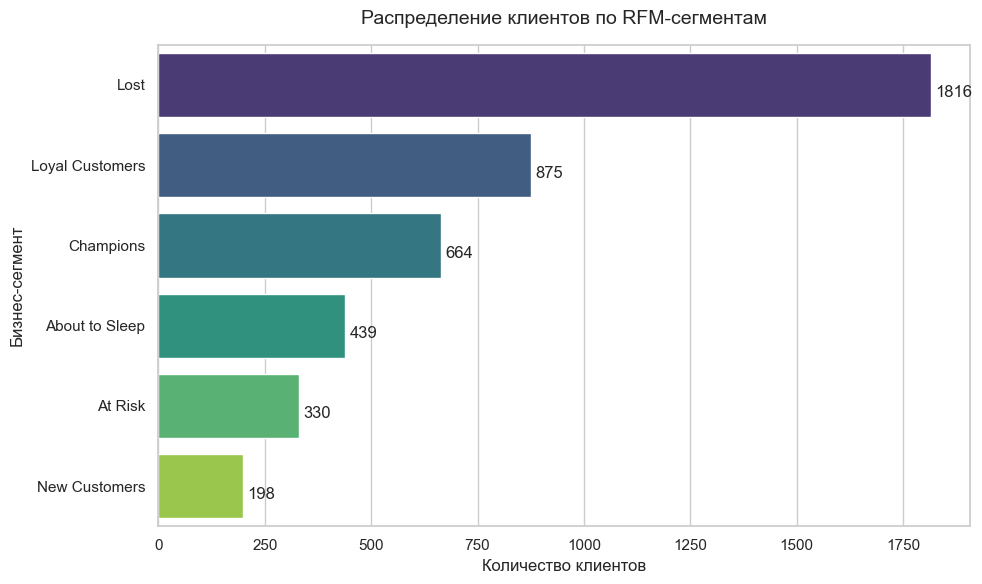

In [306]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

df_plot = rfm['Segment'].value_counts().reset_index()
df_plot.columns = ['Segment', 'Count']

ax = sns.barplot(x='Count', y='Segment', data=df_plot, palette='viridis')
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 10, p.get_y() + p.get_height()/2 + 0.1, 
            f'{int(width)}', 
            ha="left", va="center")

plt.title('Распределение клиентов по RFM-сегментам', fontsize=14, pad=15)
plt.xlabel('Количество клиентов', fontsize=12)
plt.ylabel('Бизнес-сегмент', fontsize=12)
plt.tight_layout()
plt.savefig('распределение_клиентов.png', dpi=300, bbox_inches='tight')

plt.show()

In [307]:
def get_rfm_segments(df_sales_slice, snapshot_date):
    df_slice = df_sales_slice.copy()
    if 'Monetary' not in df_slice.columns:
        df_slice['Monetary'] = df_slice['Quantity'] * df_slice['UnitPrice']
        
    rfm_slice = df_slice.groupby('CustomerID').agg({
        'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
        'InvoiceNo': 'nunique',
        'Monetary': 'sum'
    }).rename(columns={'InvoiceDate': 'Recency', 'InvoiceNo': 'Frequency'})
    
    rfm_slice = rfm_slice[rfm_slice['Monetary'] > 0]

    rfm_slice['R_Score'] = pd.qcut(rfm_slice['Recency'], 5, labels=[5, 4, 3, 2, 1])
    rfm_slice['F_Score'] = pd.qcut(rfm_slice['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
    rfm_slice['M_Score'] = pd.qcut(rfm_slice['Monetary'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])

    rfm_slice['RecencyScore'] = rfm_slice['R_Score'].astype(int)
    rfm_slice['FrequencyScore'] = rfm_slice['F_Score'].astype(int)
    rfm_slice['MonetaryScore'] = rfm_slice['M_Score'].astype(int)

    rfm_slice['Segment'] = rfm_slice.apply(assign_segment, axis=1)
    
    return rfm_slice[['Segment']]

In [308]:
min_date = df_sales_clean['InvoiceDate'].min()
max_date = df_sales_clean['InvoiceDate'].max()
median_date = min_date + (max_date - min_date) / 2

print(f"Период 1: с {min_date.date()} по {median_date.date()}")
print(f"Период 2: с {median_date.date()} по {max_date.date()}\n")

df_p1 = df_sales_clean[df_sales_clean['InvoiceDate'] <= median_date]
df_p2 = df_sales_clean[df_sales_clean['InvoiceDate'] > median_date]

snapshot_p1 = df_p1['InvoiceDate'].max() + pd.Timedelta(days=1)
snapshot_p2 = df_p2['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm_p1 = get_rfm_segments(df_p1, snapshot_p1)
rfm_p2 = get_rfm_segments(df_p2, snapshot_p2)

merged_rfm = rfm_p1.merge(rfm_p2, on='CustomerID', suffixes=('_P1', '_P2'))
transition_matrix = pd.crosstab(
    merged_rfm['Segment_P1'], 
    merged_rfm['Segment_P2'], 
    normalize='index'
) * 100

transition_matrix.round(2)

Период 1: с 2010-12-01 по 2011-06-05
Период 2: с 2011-06-05 по 2011-12-09



Segment_P2,About to Sleep,At Risk,Champions,Lost,Loyal Customers,New Customers
Segment_P1,,,,,,
About to Sleep,7.96,5.31,15.04,39.82,26.55,5.31
At Risk,4.17,15.48,27.38,30.36,22.02,0.60
Champions,0.73,11.72,57.33,10.26,19.78,0.18
Lost,9.53,11.65,12.56,44.02,18.31,3.93
Loyal Customers,3.91,17.36,26.16,27.87,24.21,0.49
New Customers,0.00,7.89,10.53,50.00,21.05,10.53


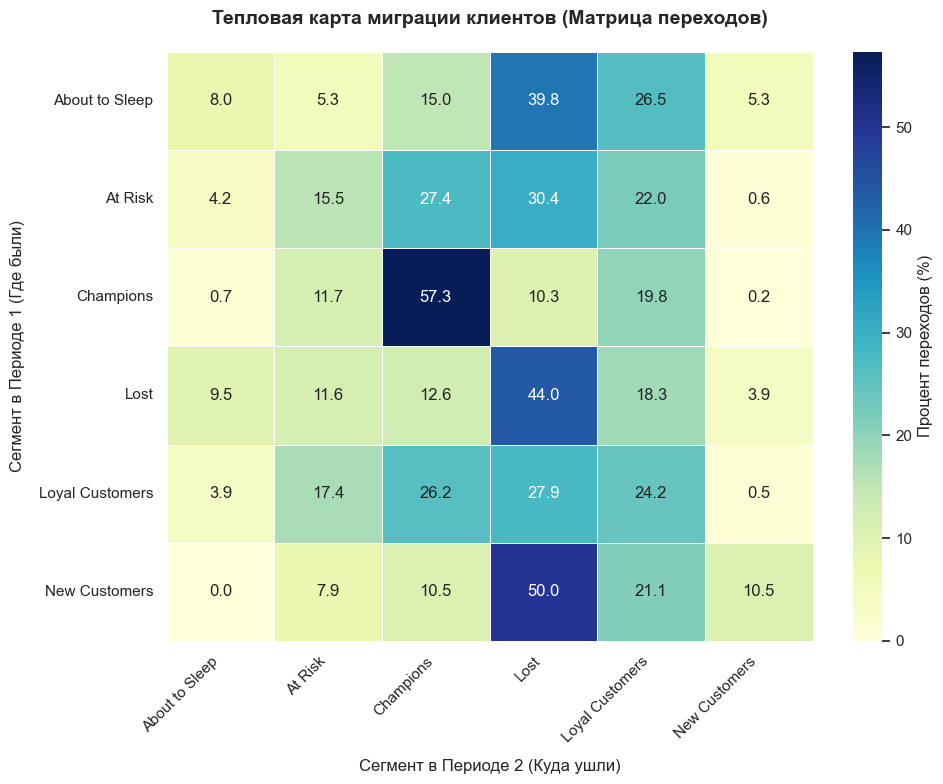

In [309]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(
    transition_matrix, 
    annot=True, 
    fmt=".1f", 
    cmap="YlGnBu", 
    linewidths=0.5, 
    cbar_kws={'label': 'Процент переходов (%)'}
)

plt.title('Тепловая карта миграции клиентов (Матрица переходов)', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Сегмент в Периоде 2 (Куда ушли)', fontsize=12, labelpad=10)
plt.ylabel('Сегмент в Периоде 1 (Где были)', fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('матрица_переходов.png', dpi=300, bbox_inches='tight')

plt.show()